# Part 4: Cluster evaluation and visualization

Quantitatively and qualitatively assess the clustering on the music feature space: load artifacts, fit/reuse KMeans, compute sanity metrics, inspect clusters, and visualize the space.

### Table of contents:
- [4.1 Setup and data loading](#41-setup-and-data-loading)
- [4.2 Fit KMeans clusters](#42-fit-kmeans-clusters)
- [4.3 Silhouette](#43-silhouette)
- [4.4 Purity / NMI / ARI against provided genres](#44-purity--nmi--ari-against-provided-genres)
- [4.5 Cluster summaries](#45-cluster-summaries)
- [4.6 Tags and representative tracks](#46-tags-and-representative-tracks)
- [4.7 PCA](#47-pca)
- [4.8 t-SNE](#48-t-sne)
- [4.9 UMAP](#49-umap)
- [4.10 Conclusion](#410-conclusion)


## 4.1 Setup and data loading

We reload the cleaned dataset and weighted feature matrix from `artifacts/`. Align common track IDs so features and metadata stay in sync. Build `X_main` as the numpy matrix we will cluster and query for neighbors. Keep `full_df` around for genres, tags, and track names when interpreting clusters.

In [35]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

notebook_dir = Path.cwd().resolve()
project_root = notebook_dir
while not (project_root / "artifacts").exists() and project_root.parent != project_root:
    project_root = project_root.parent

artifact_dir = project_root / "artifacts"

full_df_path = artifact_dir / "full_dataset_clean.csv"
features_npz_path = artifact_dir / "features_apt_all.npz"

for path in [full_df_path, features_npz_path]:
    if not path.exists():
        raise FileNotFoundError(path)

full_df = pd.read_csv(full_df_path)
features_npz = np.load(features_npz_path, allow_pickle=True)
track_ids = features_npz["track_ids"].astype(str)
weighted_features = features_npz["features_weighted"]

# Align rows so X_main matches full_df order
trackid_to_idx = {tid: i for i, tid in enumerate(track_ids)}
full_df["track_id"] = full_df["track_id"].astype(str)
full_df = full_df[full_df["track_id"].isin(trackid_to_idx)].reset_index(drop=True)
row_order = full_df["track_id"].map(trackid_to_idx).to_numpy()
X_main = weighted_features[row_order].astype(np.float32)

full_df.head()


,track_id,artists,track_name,track_genre,search_string,duration_ms,tempo,tempo_log,duration_minutes,tags_clean_text,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,lfm_playcount,lfm_listeners,log_playcount,log_listeners,log_plays_per_listener,plays_per_listener,tag_count
0,4ckoZlzQTOTEN8rhfQPbBl,Dirty Audio;Gold,No Stoppin (feat. GOLD),electronic,"No Stoppin (feat. GOLD) - Dirty Audio, Gold",160000,149.963,5.010389,2.666667,electronic usa dubstep us united state united states of america trap,0.00975,0.615,0.996,0.000142,0.0657,-0.953,0.0810,0.0797,12115.0,3312.0,9.402282,8.105609,1.538567,3.657911,7
1,3CRtbOoAP82y0VbPO5j1ft,Sasha Alex Sloan,Too Sad To Cry,electro,Too Sad To Cry - Sasha Alex Sloan,208986,120.483,4.791509,3.483100,my top song indie-pop female vocalist indie pop acoustic deezer 4-25 name variation upcoming album 2024,0.84200,0.515,0.270,0.000000,0.1140,-9.935,0.0357,0.2340,671709.0,80945.0,13.417582,11.301538,2.229836,8.298338,10
2,265SFiKBPvo5ojatV1egRk,AronChupa;Little Sis Nora,The Woodchuck Song,swedish,"The Woodchuck Song - AronChupa, Little Sis Nora",154394,126.031,4.836528,2.573233,dance electronic sweden swedish edm pop-dance club humour house hip-hop,0.01650,0.898,0.770,0.002160,0.2070,-4.970,0.3020,0.4120,228630.0,33475.0,12.339865,10.418584,2.057946,6.829873,9
3,7oQ8pTAe783QS0UwOmbHRb,Busy Signal;Mavado,Full Clip - feat. Mavado,j-dance,"Full Clip - feat. Mavado - Busy Signal, Mavado",184466,100.112,4.606290,3.074433,dancehall reggae ragga jamaican bashment busy signal jamaica caribbean all reggea,0.02610,0.726,0.692,0.000000,0.1180,-5.084,0.3340,0.5380,939.0,281.0,6.845880,5.641907,1.468251,3.341637,10
4,46Rgoqf0TIsHPudbaaqUP0,George Jones;Tammy Wynette,Did You Ever?,honky-tonk,"Did You Ever? - George Jones, Tammy Wynette",127813,74.278,4.307815,2.130217,country classic country singer-songwriter george jone americana traditional country honky tonk texa male vocalist am...,0.68500,0.613,0.295,0.000000,0.1050,-9.896,0.0303,0.8120,1262.0,453.0,7.141245,6.118097,1.331276,2.785872,10


## 4.2 Fit KMeans clusters

Use the number of distinct genres as `n_clusters` to mirror the setup we have in part 1. Fit KMeans on the full feature space and attach the label column to `full_df`. Cluster sizes printed here give a quick sense of balance or dominance.

In [36]:
from sklearn.cluster import KMeans

n_clusters = full_df["track_genre"].nunique()
print("Number of distinct genres:", n_clusters)

kmeans_main = KMeans(
    n_clusters=n_clusters,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE,
)

cluster_labels = kmeans_main.fit_predict(X_main)
full_df["cluster_kmeans_main"] = cluster_labels

cluster_sizes = full_df["cluster_kmeans_main"].value_counts().sort_index()
cluster_sizes.head()

Number of distinct genres: 113


0    563
1    378
2    210
3    686
4    455
Name: cluster_kmeans_main, dtype: int64

## 4.3 Silhouette

In the Silhouette, we meassure the internal cohesion and separation. We do the entire dataset to estimate silhouette, even though it has quadratic run time, it's okay with this amount of data: higher is tighter separation, near zero means overlap, negative means misplacement. The histogram helps spot whether most points are borderline or if there is a clean core. This is an internal metric, independent of genre labels.

In [37]:
from sklearn.metrics import silhouette_score

silhouette_full = silhouette_score(
    X_main,
    full_df["cluster_kmeans_main"].to_numpy(),
    metric="euclidean",
)
print(f"Silhouette score (n={len(X_main)}): {silhouette_full:.3f}")


Silhouette score (n=55129): 0.188


Silhouette score (n=55129): 0.188


count    55129.000000
mean         0.187508
std          0.179444
min         -0.209166
25%          0.053975
50%          0.151440
75%          0.291174
max          0.883558
dtype: float64

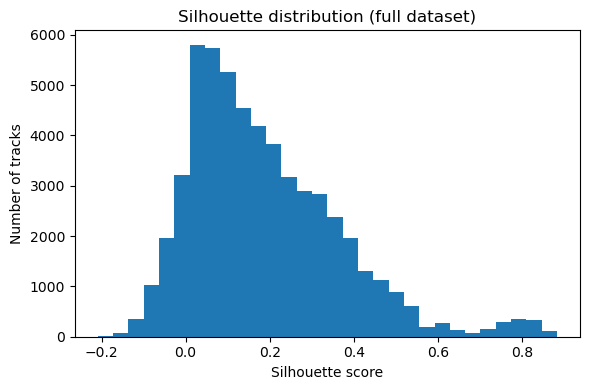

In [38]:
from sklearn.metrics import silhouette_score, silhouette_samples
import pandas as pd
import matplotlib.pyplot as plt

labels_full = full_df["cluster_kmeans_main"].to_numpy()
silhouette_full = silhouette_score(X_main, labels_full, metric="euclidean")
silhouette_full_vals = silhouette_samples(X_main, labels_full, metric="euclidean")

print(f"Silhouette score (n={len(X_main)}): {silhouette_full:.3f}")
display(pd.Series(silhouette_full_vals).describe())

plt.figure(figsize=(6, 4))
plt.hist(silhouette_full_vals, bins=30)
plt.xlabel("Silhouette score")
plt.ylabel("Number of tracks")
plt.title("Silhouette distribution (full dataset)")
plt.tight_layout()
plt.show()


Silhouette on all 55k tracks is ~0.19: modest separation. Most points are barely positive (median ~0.15, 75% ~0.29) with a thin negative tail, so clusters overlap and boundaries are fuzzy. 

## 4.4 Purity / NMI / ARI against provided genres

Compare discovered clusters against the given `track_genre` labels. Purity captures majority agreement, NMI/ARI capture mutual information and pairwise agreement; higher values mean clusters align better with genres. Treat this as a sanity check rather than the only success metric.

In [39]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

genres = full_df["track_genre"].fillna("unknown").astype(str)
clusters = full_df["cluster_kmeans_main"].to_numpy()

crosstab = pd.crosstab(clusters, genres)

majority_counts = crosstab.max(axis=1)
purity = majority_counts.sum() / len(full_df)

nmi = normalized_mutual_info_score(genres, clusters)
ari = adjusted_rand_score(genres, clusters)

print(f"Overall purity: {purity:.3f}")
print(f"NMI (clusters vs. track_genre): {nmi:.3f}")
print(f"ARI (clusters vs. track_genre): {ari:.3f}")

Overall purity: 0.469
NMI (clusters vs. track_genre): 0.584
ARI (clusters vs. track_genre): 0.229


Purity 0.47 with NMI 0.58 and ARI 0.23 means clusters capture some genre signal but are far from one-genre buckets. Many clusters mix genres; mutual information is moderate and pairwise agreement is low. We should treat genre alignment as partial: good enough for rough grouping, not for strict genre labeling

## 4.5 Cluster summaries

Here we summarize each cluster with mean feature values and size to see broad “profiles” (energy, acousticness, speechiness, etc.). Sort by size to review the largest groups first. Use this to spot outliers (e.g., very high instrumentalness or extreme loudness).

In [40]:
numeric_cols_candidate = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "valence",
    "tempo_log",
    "duration_minutes",
    "log_playcount",
    "log_listeners",
    "log_plays_per_listener",
    "tag_count",
]

numeric_cols = [c for c in numeric_cols_candidate if c in full_df.columns]

cluster_summary = (
    full_df.groupby("cluster_kmeans_main")[numeric_cols]
    .mean()
    .assign(size=lambda g: g.index.map(full_df["cluster_kmeans_main"].value_counts()))
    .sort_values("size", ascending=False)
)

cluster_summary.head(10)

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo_log,duration_minutes,log_playcount,log_listeners,log_plays_per_listener,tag_count,size
cluster_kmeans_main,,,,,,,,,,,,,,,
34,0.241432,0.664733,0.721237,0.077808,0.218913,-6.464071,0.101688,0.634982,4.896312,3.469956,8.395721,7.009453,1.636231,3.348738,3527
9,0.568746,0.585543,0.441882,0.113921,0.176966,-9.975311,0.072466,0.442457,4.617523,3.343731,8.309498,6.989696,1.588203,3.265370,2879
6,0.864423,0.338119,0.206865,0.786857,0.184046,-22.554548,0.057126,0.171028,4.574769,3.281429,8.541346,7.174785,1.647837,2.459176,1335
7,0.581165,0.518583,0.450146,0.079271,0.167660,-10.264602,0.046362,0.400895,4.750812,3.688361,11.580482,9.945469,1.826089,9.094231,1040
93,0.048205,0.452756,0.871660,0.030947,0.224906,-4.917474,0.076688,0.541780,4.904230,3.155380,10.554722,8.801129,1.922652,9.090997,1033
13,0.161696,0.515575,0.723263,0.042347,0.187745,-6.342257,0.056313,0.486745,4.805111,3.689533,12.989954,11.100040,2.041390,8.771047,974
89,0.346328,0.584064,0.581813,0.093311,0.180611,-7.823925,0.059530,0.468303,4.785544,3.432179,12.429945,10.540818,2.040593,8.604013,947
32,0.260014,0.712948,0.658000,0.014004,0.188626,-7.195045,0.196364,0.537125,4.742277,3.446415,11.138044,9.173270,2.107518,7.464883,897
8,0.125934,0.691880,0.764078,0.051635,0.194701,-5.980182,0.079117,0.623676,4.808952,3.507853,11.359330,9.676696,1.873339,8.296343,793


## 4.6 Tags and representative tracks

Here we extract most frequent tags per cluster and nearest-to-centroid tracks for quick listening candidates. This gives a qualitative feel for whether tags and exemplars match the numerical profile. Mixed tags or incoherent exemplars can flag messy clusters.

In [41]:
from collections import Counter

def top_tags_for_cluster(cluster_id, top_n=10):
    if "tags_clean_text" not in full_df.columns:
        return []
    mask = full_df["cluster_kmeans_main"] == cluster_id
    tags_series = full_df.loc[mask, "tags_clean_text"].fillna("")
    counter = Counter()
    for s in tags_series:
        if not s:
            continue
        for t in s.split():
            counter[t] += 1
    return counter.most_common(top_n)

first_cluster = int(cluster_summary.index[0])
top_tags_for_cluster(first_cluster, top_n=10)

[('pop', 557),
 ('rock', 471),
 ('brazilian', 432),
 ('brazil', 380),
 ('vocalist', 318),
 ('brasil', 292),
 ('electronic', 243),
 ('female', 207),
 ('all', 199),
 ('american', 199)]

In [42]:
from sklearn.metrics import pairwise_distances

def representative_tracks(cluster_id, top_n=5):
    mask = full_df["cluster_kmeans_main"] == cluster_id
    indices = np.where(mask.to_numpy())[0]
    if len(indices) == 0:
        return full_df.iloc[[]]

    center = kmeans_main.cluster_centers_[cluster_id]
    X_cluster = X_main[indices]
    dists = pairwise_distances(X_cluster, center.reshape(1, -1), metric="euclidean").ravel()
    order = np.argsort(dists)[:top_n]
    chosen = indices[order]
    return full_df.loc[chosen, ["track_id", "artists", "track_name", "track_genre"]]

representative_tracks(first_cluster, top_n=5)

,track_id,artists,track_name,track_genre
28630,2uyYcVToGd0P3twslT6Qzn,DJ Black Rock,GDFR (Going Down for Real),kids
26620,0U7SRbyBhkdXdulXr3veKQ,Kevi Jonny,Aquele Story,forro
52645,6Eo1tU0Zw7Bgw3cPtVKxRX,Balek,112,party
39486,11CrYElJH7l26yy5Tb5Ihy,Matadoria,Vettam,malay
48268,6JilFqhtGTaEdKH6EYf10j,Kevi Jonny,Arranhão,forro


In [43]:
def describe_cluster(cluster_id, top_n_tags=10, top_n_tracks=5):
    if "cluster_kmeans_main" not in full_df.columns:
        raise ValueError("cluster_kmeans_main not found; run clustering cell first.")

    mask = full_df["cluster_kmeans_main"] == cluster_id
    size = int(mask.sum())
    if size == 0:
        print(f"Cluster {cluster_id} has no rows.")
        return

    genres = full_df.loc[mask, "track_genre"].value_counts().head(5)
    means = full_df.loc[mask, numeric_cols].mean() if numeric_cols else pd.Series(dtype=float)

    print(f"Cluster {cluster_id}")
    print(f"Size: {size}")
    print("Top genres:")
    print(genres)
    print("Mean feature profile:")
    print(means.round(3))
    print("Top tags:")
    print(top_tags_for_cluster(cluster_id, top_n=top_n_tags))
    print("Representative tracks:")
    display(representative_tracks(cluster_id, top_n=top_n_tracks))

if "cluster_summary" not in globals():
    cluster_summary = (
        full_df.groupby("cluster_kmeans_main")[numeric_cols]
        .mean()
        .assign(size=lambda g: g.index.map(full_df["cluster_kmeans_main"].value_counts()))
        .sort_values("size", ascending=False)
    )

cluster_ids = list(cluster_summary.index[:5])
for cid in cluster_ids:
    describe_cluster(int(cid))


Cluster 34
Size: 3527
Top genres:
kids        296
forro       201
party       153
children    148
malay       138
Name: track_genre, dtype: int64
Mean feature profile:
acousticness              0.241
danceability              0.665
energy                    0.721
instrumentalness          0.078
liveness                  0.219
loudness                 -6.464
speechiness               0.102
valence                   0.635
tempo_log                 4.896
duration_minutes          3.470
log_playcount             8.396
log_listeners             7.009
log_plays_per_listener    1.636
tag_count                 3.349
dtype: float64
Top tags:
[('pop', 557), ('rock', 471), ('brazilian', 432), ('brazil', 380), ('vocalist', 318), ('brasil', 292), ('electronic', 243), ('female', 207), ('all', 199), ('american', 199)]
Representative tracks:


,track_id,artists,track_name,track_genre
28630,2uyYcVToGd0P3twslT6Qzn,DJ Black Rock,GDFR (Going Down for Real),kids
26620,0U7SRbyBhkdXdulXr3veKQ,Kevi Jonny,Aquele Story,forro
52645,6Eo1tU0Zw7Bgw3cPtVKxRX,Balek,112,party
39486,11CrYElJH7l26yy5Tb5Ihy,Matadoria,Vettam,malay
48268,6JilFqhtGTaEdKH6EYf10j,Kevi Jonny,Arranhão,forro


Cluster 9
Size: 2879
Top genres:
study          226
malay          186
honky-tonk     144
disney         128
rock-n-roll    120
Name: track_genre, dtype: int64
Mean feature profile:
acousticness              0.569
danceability              0.586
energy                    0.442
instrumentalness          0.114
liveness                  0.177
loudness                 -9.975
speechiness               0.072
valence                   0.442
tempo_log                 4.618
duration_minutes          3.344
log_playcount             8.309
log_listeners             6.990
log_plays_per_listener    1.588
tag_count                 3.265
dtype: float64
Top tags:
[('pop', 573), ('country', 392), ('vocalist', 364), ('rock', 281), ('singer-songwriter', 253), ('male', 232), ('female', 201), ('all', 181), ('american', 170), ('brazilian', 151)]
Representative tracks:


,track_id,artists,track_name,track_genre
32919,3RDDPTFuikYlu0A4OXCCkl,Nicolas Candido,Hoje Caminhei,mpb
16945,1IF1IpJ8SnBDgHO5Nig0pD,"Francisco, el Hombre",O TEMPO É SUA MORADA :: celebrar,mpb
33243,5qG6pu4Vq9f7wB0NAso4UN,King Shubh;King,Ghumshudaa (Lofi Flip) [feat. King],indian
33350,4tm6TQQGoUdOfCYh639No1,Talita Barreto,Ele É,groove
4595,1z9GHAYy5cSzeh4rRnafSN,Sonia Rivas,Con Tu Misma Moneda,rock-n-roll


Cluster 6
Size: 1335
Top genres:
sleep        355
disney       137
piano        122
classical    106
study        101
Name: track_genre, dtype: int64
Mean feature profile:
acousticness               0.864
danceability               0.338
energy                     0.207
instrumentalness           0.787
liveness                   0.184
loudness                 -22.555
speechiness                0.057
valence                    0.171
tempo_log                  4.575
duration_minutes           3.281
log_playcount              8.541
log_listeners              7.175
log_plays_per_listener     1.648
tag_count                  2.459
dtype: float64
Top tags:
[('ambient', 238), ('classical', 150), ('electronic', 142), ('experimental', 85), ('american', 73), ('noise', 71), ('composer', 67), ('all', 63), ('drone', 56), ('downtempo', 54)]
Representative tracks:


,track_id,artists,track_name,track_genre
48847,4j63MsY1JhofTuai9FwWb3,Pyotr Ilyich Tchaikovsky;Una Bourne,"2 Pieces for Piano, Op. 10, TH 132: No. 2, Humoresque. Allegretto scherzando",classical
28294,6bpRlS4YiYLCsylFcLfX4m,Yiruma,Poem+,new-age
31858,1VsXbdekUKQ0KJIBaqC96E,Franz Schubert;Yanica Hristova,"4 Impromptus, Op. 90, D. 899: II. Allegro - Coda",classical
21785,5aQo0YEgGT3IEujA4Bj8kf,Piano Radiance,My Heart Will Go On,disney
12244,039sj87NWcViw10cfxBIsv,Edvard Grieg;Una Bourne,"Lyric Pieces III, Op. 43 (Excerpts): No. 6, Til foråret",classical


Cluster 7
Size: 1040
Top genres:
acoustic    327
folk        106
british      95
ambient      79
afrobeat     46
Name: track_genre, dtype: int64
Mean feature profile:
acousticness               0.581
danceability               0.519
energy                     0.450
instrumentalness           0.079
liveness                   0.168
loudness                 -10.265
speechiness                0.046
valence                    0.401
tempo_log                  4.751
duration_minutes           3.688
log_playcount             11.580
log_listeners              9.945
log_plays_per_listener     1.826
tag_count                  9.094
dtype: float64
Top tags:
[('folk', 1904), ('indie', 919), ('singer-songwriter', 698), ('acoustic', 677), ('rock', 643), ('vocalist', 531), ('pop', 484), ('male', 326), ('alternative', 293), ('american', 268)]
Representative tracks:


,track_id,artists,track_name,track_genre
36586,3avWV9e8Z0o6RMMHh9ysZF,Bhoomi,Lal Paharir Deshe Ja,indie-pop
19381,4yyg2J2uXOjCtCyT64984C,Lord Huron,Ends of the Earth,folk
469,34f6sZPLPVsGwgBOrW3iLu,Roo Panes,Land Of The Living,british
33327,2ixsaeFioXJmMgkkbd4uj1,George Ezra,Budapest,folk
31808,3EgC9peIAOtKROIHsRqVVZ,Robert John Ardiff,People Talking,dub


Cluster 93
Size: 1033
Top genres:
power-pop    245
punk-rock    175
hardcore     119
emo           99
punk          61
Name: track_genre, dtype: int64
Mean feature profile:
acousticness               0.048
danceability               0.453
energy                     0.872
instrumentalness           0.031
liveness                   0.225
loudness                  -4.917
speechiness                0.077
valence                    0.542
tempo_log                  4.904
duration_minutes           3.155
log_playcount             10.555
log_listeners              8.801
log_plays_per_listener     1.923
tag_count                  9.091
dtype: float64
Top tags:
[('punk', 3289), ('rock', 2113), ('pop', 855), ('hardcore', 471), ('alternative', 405), ('american', 331), ('melodic', 280), ('pop-punk', 239), ('emo', 149), ('indie', 145)]
Representative tracks:


,track_id,artists,track_name,track_genre
37235,6yOr6vYhgHmYjhrmmlfd6s,Rybičky 48,Jdi domů Ivane,punk-rock
9984,4JAtDXVF8f5OgCkz1vEAfU,Rybičky 48,Muži,punk-rock
43840,5pcfYLrIw2w5TmmDBkKDkB,Rybičky 48,Bohém zapomenutý dítě,punk-rock
43573,5hRYqAIsLf6I7zRP3wOoLw,Tronic,Fenix,punk-rock
18310,1CrCjB0ihP0OBPMHYwviF0,Nekromantix,Dead Girls Don't Cry,psych-rock


These cluster readouts show how well numeric clusters line up with intuitive feeling:

1. 34: high danceability and energy, Brazil, brazilian pop, party mix; tags are broad, so it’s a loose high-energy bucket.
2. 9: mid-energy acoustic,singer-songwriter,country, Disney blend; softer loudness and balanced valence.
3. 6: very acoustic, low-energy, high instrumentalness so sleep, ambient, classical piano is coherent tags.
4. 7: folk, acoustic, indie singer-songwriter so moderate energy/valence and rich tag counts.
5. 93: loud, high-energy punk, power-pop so tags and reps align tightly.


## 4.7 PCA

Here we project a sampled subset into 2D and below we do 3D via PCA to see broad separation. Linear projections can smear nonlinear structure but are fast and reproducible and we can look for whether major clusters form distinguishable blobs or overlap heavily.

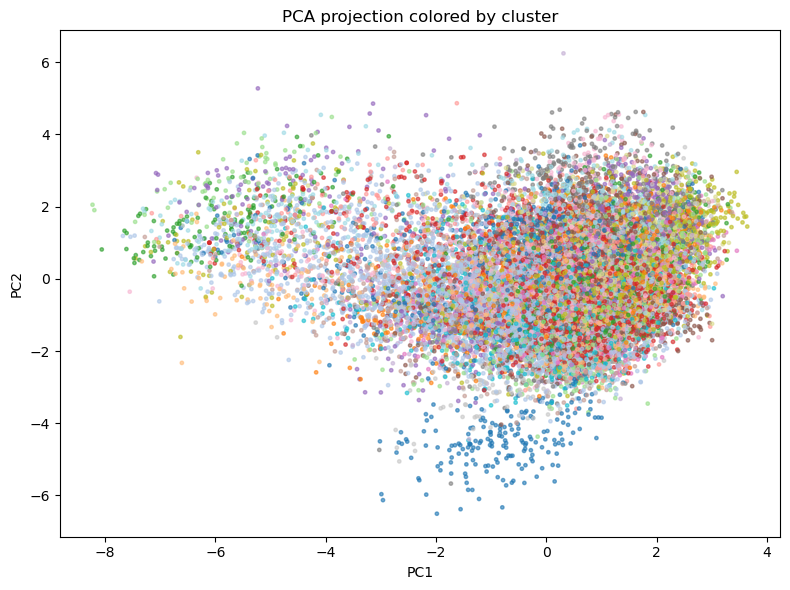

In [44]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

n_samples = X_main.shape[0]
max_sample = 20000

if n_samples > max_sample:
    rng = np.random.RandomState(RANDOM_STATE)
    vis_indices = rng.choice(n_samples, size=max_sample, replace=False)
else:
    vis_indices = np.arange(n_samples)

X_vis = X_main[vis_indices]
clusters_vis = full_df.loc[vis_indices, "cluster_kmeans_main"].to_numpy()

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_vis)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_vis, s=6, alpha=0.6, cmap="tab20")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection colored by cluster")
plt.tight_layout()
plt.show()

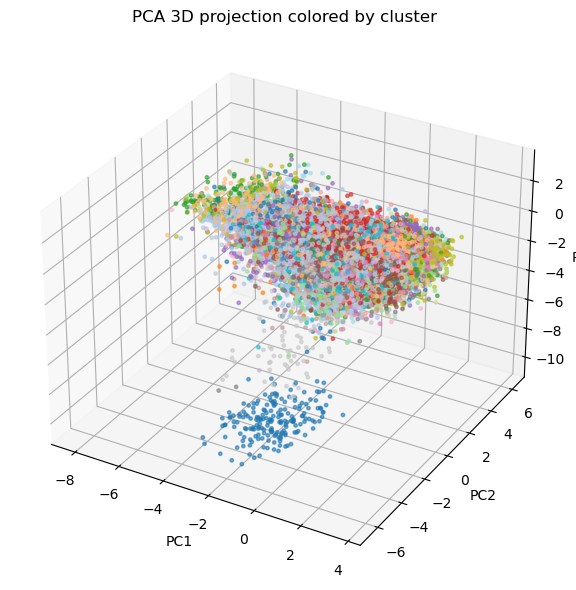

In [45]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

n_samples = X_main.shape[0]
max_sample = 20000
if n_samples > max_sample:
    rng = np.random.RandomState(RANDOM_STATE)
    vis_indices = rng.choice(n_samples, size=max_sample, replace=False)
else:
    vis_indices = np.arange(n_samples)

X_vis = X_main[vis_indices]
clusters_vis = full_df.loc[vis_indices, "cluster_kmeans_main"].to_numpy()

pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca3.fit_transform(X_vis)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=clusters_vis, s=6, alpha=0.6, cmap="tab20")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA 3D projection colored by cluster")
plt.tight_layout()
plt.show()


## 4.8 t-SNE

We try to look at nonlinear local structure by using t-SNE on a smaller sample to inspect local neighborhoods. Expect some overlap; well-separated islands suggest stronger local consistency. 

t-SNE sample size: 10000, perplexity: 30
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 0.240s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 2.377544
[t-SNE] KL divergence after 250 iterations with early exaggeration: 86.825821
[t-SNE] KL divergence after 1000 itera

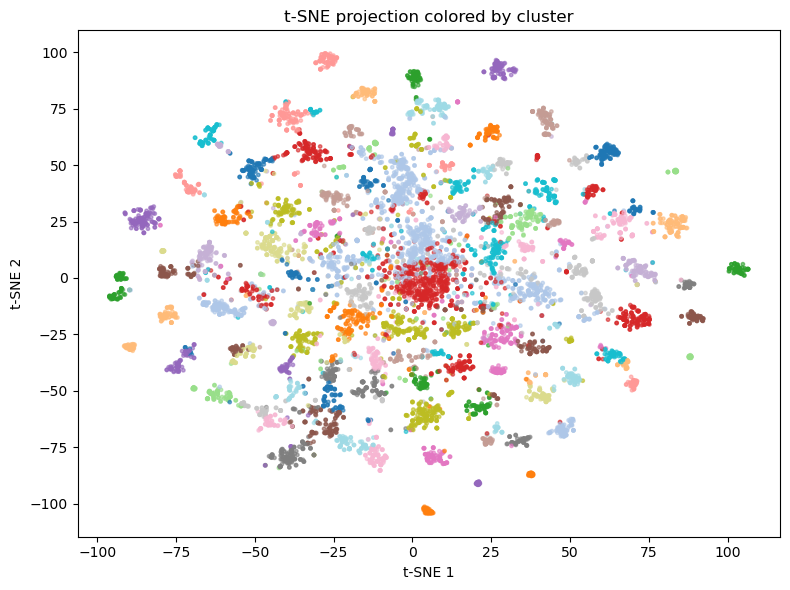

In [46]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

max_tsne = 10000

if n_samples > max_tsne:
    rng = np.random.RandomState(RANDOM_STATE)
    tsne_indices = rng.choice(n_samples, size=max_tsne, replace=False)
else:
    tsne_indices = np.arange(n_samples)

X_tsne_in = X_main[tsne_indices]
clusters_tsne = full_df.loc[tsne_indices, "cluster_kmeans_main"].to_numpy()

n_tsne = len(tsne_indices)
if n_tsne <= 10:
    raise ValueError(f"Not enough samples for t-SNE (got {n_tsne})")
perplexity = min(30, max(5, n_tsne // 3))
if perplexity >= n_tsne:
    perplexity = max(5, n_tsne - 1)

print(f"t-SNE sample size: {n_tsne}, perplexity: {perplexity}")

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate=200,
    metric="euclidean",
    init="random",
    random_state=RANDOM_STATE,
    verbose=1,
)

X_tsne = tsne.fit_transform(X_tsne_in)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters_tsne, s=6, alpha=0.6, cmap="tab20")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection colored by cluster")
plt.tight_layout()
plt.show()

## 4.9 UMAP

We use UMAP to look at more nonlinear both global and local structure. Alternative nonlinear 2D view that balances global and local structure. We compare its layout to t-SNE to see if clusters separate more clearly.

/Users/andreas/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


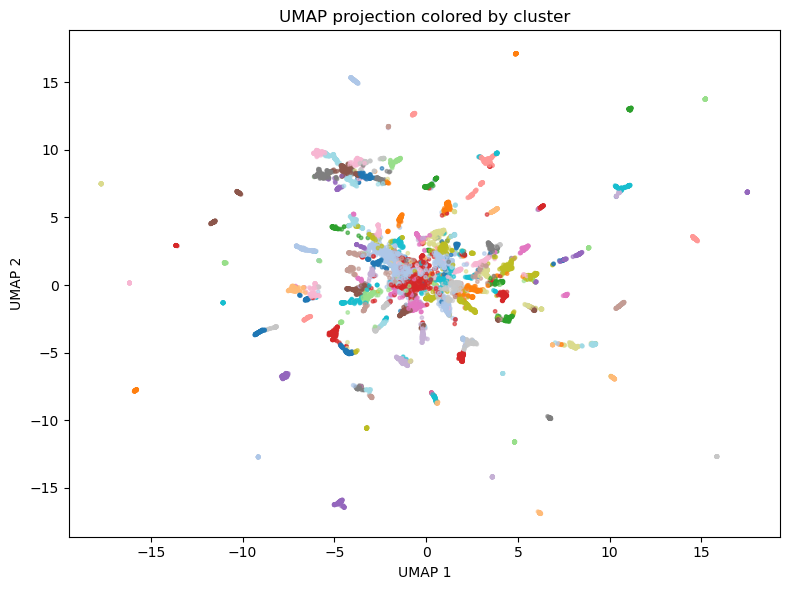

In [47]:
import umap
import matplotlib.pyplot as plt

max_umap = 10000
if X_main.shape[0] > max_umap:
    rng = np.random.RandomState(RANDOM_STATE)
    umap_indices = rng.choice(X_main.shape[0], size=max_umap, replace=False)
else:
    umap_indices = np.arange(X_main.shape[0])

X_umap_in = X_main[umap_indices]
clusters_umap = full_df.loc[umap_indices, "cluster_kmeans_main"].to_numpy()

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=25,
    min_dist=0.15,
    metric="euclidean",
    random_state=RANDOM_STATE,
)
X_umap = reducer.fit_transform(X_umap_in)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters_umap, s=6, alpha=0.6, cmap="tab20")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP projection colored by cluster")
plt.tight_layout()
plt.show()


## 4.10 Conclusion

Silhouette on the full set (~0.19) and purity/NMI/ARI (0.47/0.58/0.23) show only modest separation and partial genre alignment—clusters are usable for loose grouping, not strict labels. Visualizations (PCA/t-SNE/UMAP) and summaries confirm some crisp clusters (for example: sleep, ambient, punk) but also broad mixed ones (for example: high-energy party, Brazil). Subjective bias checks can surface whether recs overrepeat artists/genres; retuning `n_clusters` or feature weights would be the next lever to improve separation.

In general it can be a little hard to meassure, whether a music recommendation system is good, because it's often quite subjective. But we have done some subjective checks throughout the notebook which further improves our confidence.